In [25]:
%pip install torch==2.6.0
%pip install torchvision==0.21.0
%pip install matplotlib==3.10.1
%pip install scikit-learn==1.6.1
%pip install tdqm==0.0.1
%pip install numpy==1.24.1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.24.1.tar.gz (10.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "/home/ubuntu/persistent/144Venv/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/home/ubuntu/persistent/144Venv/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["ret

In [1]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import trange
import os
from tqdm import tqdm
import pathlib
from torchvision.io import decode_image
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
from torchvision.transforms import v2
from torch.utils.data import Dataset, Subset
import torchvision.models as models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Use hardware acceleration if availaible

In [2]:
# https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

cuda


### Utility Function: Gets path to model file

In [3]:
# Get path to model, if it exists
def getModelPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)
    
    if 'model' in dir_list:
        model_dir_path = os.path.join(path,'model')
    else:
        raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dir_path)
    timestr = time.strftime("%Y%m%d_%H%M%S")
    model_file_name = os.path.join(model_dir_path,timestr) + ".pth"

    return model_file_name

### Utility Function: Gets path to weights file

In [4]:
# Get path to weights, if it exists
def getWeightsPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)
    
    if 'weights' in dir_list:
        weights_dir_path = os.path.join(path,'weights')
    else:
        raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dir_path)
    timestr = time.strftime("%Y%m%d_%H%M%S")
    model_file_name = os.path.join(weights_dir_path,timestr) + ".pth"

    return model_file_name

# How to read the data
* Reading the data
* Putting the image stright into ram is not a good idea
* I think maybe I will be using a CSV file that store the classification of the image and the path to the image. 

In [5]:
# https://www.geeksforgeeks.org/python-list-files-in-a-directory/
# https://stackoverflow.com/questions/3430372/how-do-i-get-the-full-path-of-the-current-files-directory
# https://stackoverflow.com/questions/431684/how-do-i-change-the-working-directory-in-python
path = pathlib.Path().resolve()
dir_list = os.listdir(path)
if 'train' in dir_list:
    train_dir_path = os.path.join(os.path.join(path,'train'),'train')
else:
    raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"" + os.path.join(path,'train') + "\"")

# Setting up transform for the image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data
* https://pytorch.org/vision/0.9/transforms.html

In [6]:
# transform = transforms.Compose()
# Define transformations
transform = transforms.Compose([
    transforms.Resize(1024),  # Resize the smaller side to 1024 while keeping aspect ratio
    transforms.Pad(padding=0, fill=0, padding_mode="constant"),  # Padding to square shape
    transforms.CenterCrop((1024, 1024)),  # Ensure final size
    transforms.ToTensor(),
])

# Import image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

In [7]:

dataset = datasets.ImageFolder(train_dir_path, transform=transform)

# Image augmentation
* Adversarial attack (Suggested by Johnson)
* Flip
* Inverse
* Rotate
* Zoom

### Resourse on doing augmentation
* https://pytorch.org/vision/main/transforms.html

# Image augmentation function
* https://pytorch.org/vision/main/transforms.html

In [8]:
AUGMENTATIONS: list[v2.Transform] = [
    v2.GaussianNoise(),
    v2.RandomSolarize(threshold=0.1),
    v2.ColorJitter(),
    v2.RandomRotation(degrees=90),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomInvert(),
    v2.RandomCrop(size=(224,224)),
    v2.RandomChannelPermutation(),
    # v2.Grayscale(),
    v2.RandomAutocontrast(),
    v2.RandomEqualize(),
]


AUGMENTATIONS = v2.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    v2.AutoAugment(policy=v2.AutoAugmentPolicy.CIFAR10),  # Uses augmentation strategies learned from CIFAR-10
    v2.GaussianNoise(),  # Additive noise for robustness (not included in AutoAugment)
    # transforms.ToTensor(),  # Convert PIL image to tensor
])

MAX_RANDOM_AUGMENTATIONS: int = 10
NUM_AUGMENTATIONS: int = 16

In [9]:
def randomTransform() -> list[v2.Transform]:
    transformations: list[v2.Transform] = []
    numRandomAugmentation: int = random.randint(1, MAX_RANDOM_AUGMENTATIONS)
    
    for _ in range(numRandomAugmentation):
        transformations.append(random.choice(AUGMENTATIONS))
        
    transformations.append(v2.Normalize(mean=[0.485, 0.456, 0.406] ,std=[0.229, 0.224, 0.225]))
    transformations.append(v2.Resize((224,224)))
    return v2.Compose(transformations)

In [10]:
# Horizontally flip each image at the given probability
def augment_images(images: torch.Tensor, labels: torch.Tensor) -> tuple:
    augmented_images = []
    augmented_labels = []

    resize_transform = v2.Resize((224, 224))  # Ensure final size consistency
    
    # Create multiple augmentations for each image
    for i, image in enumerate(images):
        # Create 4 augmentations for each image

        rand: int = random.randint(0, NUM_AUGMENTATIONS-1)

        for j in range(NUM_AUGMENTATIONS):
            # keep original image untouched
            augmented = None
            if(j == rand):
                augmented = image
            else:
                # Create a new transform composition for each augmentation
                # transforms2 = randomTransform()
                transforms2 = AUGMENTATIONS
                # Apply the transform directly
                augmented = transforms2(image)

            augmented = resize_transform(augmented)  # Resize to (224, 224)
            augmented_images.append(augmented)
            augmented_labels.append(labels[i])

    # return torch.stack(augmented_images), torch.tensor(augmented_labels)
    
    # Convert lists to tensors first
    augmented_images_tensor = torch.stack(augmented_images)
    augmented_labels_tensor = torch.stack(augmented_labels)

    # Generate a random permutation index
    perm = torch.randperm(len(augmented_images_tensor))

    # Shuffle both tensors
    augmented_images_tensor = augmented_images_tensor[perm]
    augmented_labels_tensor = augmented_labels_tensor[perm]

    
    return augmented_images_tensor, augmented_labels_tensor

In [11]:
# Setting up cutmix and mixup
cutmix = v2.CutMix(num_classes=100)
mixup = v2.MixUp(num_classes=100)
cut_mix_augment = v2.Compose([
    v2.RandomChoice([cutmix, mixup]),
    v2.Resize((224, 224))
])

def cut_mix_up(x_batch, y_batch):
    image_tensor, labels_tensor = cut_mix_augment(x_batch, y_batch)
    return image_tensor,labels_tensor

In [12]:
# plt.figure(figsize=(20, 20))

# train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.9,0.1])

# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# # Test the function
# images, labels = next(iter(test_loader))

# augmented_batch, augmented_labels = augment_images(images[:5], labels[:5])  # Get 5 images and their augmentations
# print(f"Original images shape: {images[:5].shape}")
# print(f"Augmented images shape: {augmented_batch.shape}")
# print(f"Augmented labels shape: {augmented_labels.shape}")

# # Plot original and augmented images
# for i in range(5):
#     for j in range(NUM_AUGMENTATIONS):
#         plt.subplot(5, 5, i * 5 + j + 1)
#         plt.imshow(augmented_batch[i * NUM_AUGMENTATIONS + j].permute(1, 2, 0).cpu())  # Convert from CxHxW to HxWxC
        
#         if j == 0:
#             plt.title(f"Original {i+1}")
#         else:
#             plt.title(f"Augment {j}")
        
#         plt.axis("off")

# plt.tight_layout()
# plt.show()

# Learning transfer learning from exercise
* https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs?usp=sharing

In [13]:
NUM_CLASSES: int = 100

# # Define custom classification head
# class ResNetHead(nn.Module):
#     def __init__(self, in_features=3712, num_classes=100):  # Adjust `in_features` to match RegNet output
#         super(ResNetHead, self).__init__()
#          # self.avgpool = nn.AdaptiveAvgPool2d(1)
#         self.classifier = nn.Sequential(
#             nn.Linear(in_features, 1000),
#             nn.Dropout(p=0.4),
#             nn.ReLU(),
#             nn.Linear(1000, num_classes),
#             # nn.Linear(in_features, num_classes),
#         )

#     def forward(self, x):
#         # x = self.avgpool(x)
#         return self.classifier(x)

# # Load pretrained RegNet model
# base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2.DEFAULT).to(device)

# # print(base_model)
# # Remove the original classifier (fc layer) and add our custom head
# in_features = base_model.fc.in_features  # Get input features of last linear layer
# base_model.fc = ResNetHead(in_features=in_features, num_classes=100).to(device)  # Replace with custom head

# # Verify Model Architecture
# print(base_model)

# Define Custom Classification Head for ViT
class ViTHead(nn.Module):
    def __init__(self, in_features=768, num_classes=100):  # Adjust `in_features` to match ViT output
        super(ViTHead, self).__init__()
        self.classifier = nn.Sequential(
            # nn.Linear(in_features, 1000),
            # nn.Dropout(p=0.4),
            # nn.ReLU(),
            # nn.Linear(1000, num_classes),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

# Load pretrained ViT model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = models.vit_l_16(weights=models.ViT_L_16_Weights.IMAGENET1K_V1).to(device)

# Extract the number of input features for the classification head
in_features = base_model.heads.head.in_features  

# Replace the classification head with a custom 

base_model.heads.head = ViTHead(in_features=in_features, num_classes=NUM_CLASSES).to(device)

# Verify Model Architecture
print(base_model)

VisionTransformer(
  (conv_proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=4096, out_features=1024, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
       

In [14]:
# Freeze all layers first
for param in base_model.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block (block4 in RegNet)
# for param in base_model.trunk_output[3].parameters():  # Block 4 in trunk_output
#     param.requires_grad = True

# Unfreeze the classification head (fc layer)
for param in base_model.heads.head.parameters():
    param.requires_grad = True

for name, param in base_model.named_parameters():
    if param.requires_grad:
        print(f"Trainable: {name}")

# Verify trainable parameters
trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in base_model.parameters())
print(f"Trainable Parameters: {trainable_params}/{total_params}")

Trainable: heads.head.classifier.0.weight
Trainable: heads.head.classifier.0.bias
Trainable Parameters: 102500/303404132


# Setting up the nn
* This code is from https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs#scrollTo=3kTYygi258Yv
* https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html#torch.optim.lr_scheduler.ReduceLROnPlateau

In [15]:
SHOULD_LOAD_MODEL_FROM_DISK = False

if SHOULD_LOAD_MODEL_FROM_DISK:
    base_model.load_state_dict(torch.load(getModelPath(), weights_only=True))
    base_model.eval()


criterion = nn.CrossEntropyLoss()

In [16]:
REGULARIZATION_LAMDA = 0.0001
REGULARIZATION_MODE = 2

In [17]:
def regularization(model,mode):
    if(mode == 1):
        return sum(p.abs().sum() for p in model.parameters())
    elif(mode == 2):
        return sum(p.pow(2).sum() for p in model.parameters())
    else:
        return 0

In [18]:
# Custom collate function for one-hot encoding labels
def one_hot_collate_fn(batch):
    images, labels = zip(*batch)  # Unpack batch into images and labels
    images = torch.stack(images)  # Stack images into a tensor
    labels = F.one_hot(torch.tensor(labels), NUM_CLASSES).float()  # Convert labels to one-hot encoding
    return images, labels

# Accuracy calculation
* https://pytorch.org/docs/stable/generated/torch.nn.functional.one_hot.html

In [19]:
# Function to calculate accuracy
def accuracy(loader, base_model):
    base_model.eval()  # Put model in eval model so no weight updates
    correct = 0
    total = 0
    loss = 0
    total_batches = 0
    resize_transform = v2.Resize((224, 224))  # Ensure final size consistency

    with torch.no_grad():
        for data in loader:
            image, label = data

            image = resize_transform(image)

            image, label = image.to(device=device), label.to(device=device)
            with torch.no_grad():
              output = base_model(image)

            _, predicted = torch.max(output.data, 1)

            loss += criterion(output, label)
            loss.cpu()
            
            total += label.size(0)
            correct += (predicted == label).sum().item()
            total_batches += 1
    return loss / total_batches, correct / total

def MyhillNerode(*args):
    return accuracy(*args)

# Training

In [20]:
def augmentDataset (train_loader, batch_size):
    # Lists to store augmented data
    augmented_images_list = []
    augmented_labels_list = []

    # Apply augmentation to each batch
    for x_batch, y_batch in train_loader:
        
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        x_batch_aug, y_batch_aug = augment_images(x_batch, y_batch) 

        x_batch_mix, y_batch_mix = cut_mix_up(x_batch, y_batch) 
        
        augmented_images_list.append(x_batch_aug)
        augmented_images_list.append(x_batch_mix)

        augmented_labels_list.append(y_batch_aug)
        augmented_labels_list.append(y_batch_mix)

    # Concatenate all augmented batches
    augmented_images_tensor = torch.cat(augmented_images_list, dim=0)
    augmented_labels_tensor = torch.cat(augmented_labels_list, dim=0)

    # Create a new dataset from augmented data
    augmented_train_dataset = TensorDataset(augmented_images_tensor, augmented_labels_tensor)

    # Create a DataLoader from augmented data
    augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=False)

    return augmented_train_loader

In [21]:
import torch.utils
import torch.utils.data
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset

class BaileyNetwork:
    def __init__(self, optimizer, base_model, scheduler):
        self.optimizer = optimizer
        self.base_model = base_model
        self.scheduler = scheduler

    def train(self, dataset: Dataset, epochs=10, num_batches=10):

        losses_train, losses_val = [], []
        accs_val = []

        batch_size = int(len(dataset) / num_batches)

        train_split = 0.9
        val_split = 1- train_split

        train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_split, val_split])

        for epoch_id in tqdm(range(epochs)):

            self.base_model.train()

            epoch_loss = 0
            val_loss = 0

            train_acc = 0
            val_acc = 0

            train_correct = 0
            train_total = 0
            train_batches = 0

            # train_loader = DataLoader(train_dataset, batch_size=100, shuffle=False)

            train_loader = DataLoader(dataset, batch_size=100, shuffle=True, collate_fn=one_hot_collate_fn)

            augmented_train_loader = augmentDataset(train_loader, batch_size)

            val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

            # Get the batch data 
            for x_batch, y_batch in augmented_train_loader: 

                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                self.optimizer.zero_grad()      # Reset grad to zero

                outputs = self.base_model(x_batch)                 # Running our model
                
                loss = criterion(outputs, y_batch)          # Calculating the loss

                # loss += REGULARIZATION_LAMDA * regularization(self.base_model,REGULARIZATION_MODE) 

                loss.backward()                                  # Back propagation 

                # Update parameters using the optimizer 
                self.optimizer.step()                                 # Update parameters

                _, predicted = torch.max(outputs.data, 1)
                _, y_label_max = torch.max(y_batch, 1)
                
                train_correct += (predicted == y_label_max).sum().item()
                train_total += len(x_batch)

                # per fold loss calcualtion
                epoch_loss += loss.item()
                train_batches += 1

            
            loss_val, val_acc = MyhillNerode(val_loader, self.base_model)

            epoch_loss = epoch_loss / (train_batches)
            train_acc = train_correct / (train_total)

            # Print epoch statistics
            self.scheduler.step(loss_val)

            losses_train.append(epoch_loss)
            losses_val.append(loss_val)
            accs_val.append(val_acc)

            print(f"Epoch {epoch_id + 1}/{epochs}, Training Loss: {epoch_loss:.4f}, Training ACC: {train_acc:.4f}, Validation Loss: {loss_val:.4f}, Validation ACC: {val_acc:.4f}")

        return losses_train, losses_val, accs_val

# Training

#### Hyperparameters

In [22]:
EPOCHS: int = 50
BATCHES: int = 10
LEARNING_RATE: float = 0.005

In [23]:
optimizer = torch.optim.AdamW(base_model.parameters(), lr=LEARNING_RATE, eps=1e-08, weight_decay=0.01)

# warmup_steps is the number of steps to increase the learning rate to the target learning rate
warmup_steps = 1000  # Adjust based on your dataset size and batch size
scheduler_warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup_steps)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

trainer = BaileyNetwork(optimizer=optimizer, base_model=base_model, scheduler=scheduler)

In [24]:
losses_train, losses_val, accs_val = trainer.train(dataset,epochs=EPOCHS, num_batches=BATCHES) 

  2%|▏         | 1/50 [03:31<2:52:52, 211.68s/it]

Epoch 1/50, Training Loss: 3.1607, Training ACC: 0.2848, Validation Loss: 1.7422, Validation ACC: 0.5556


  4%|▍         | 2/50 [07:05<2:50:15, 212.82s/it]

Epoch 2/50, Training Loss: 1.8443, Training ACC: 0.5595, Validation Loss: 1.1199, Validation ACC: 0.7576


  6%|▌         | 3/50 [10:37<2:46:31, 212.58s/it]

...

Epoch 48/50, Training Loss: 0.3331, Training ACC: 0.9475, Validation Loss: 0.0419, Validation ACC: 0.9899


 98%|█████████▊| 49/50 [2:48:19<03:30, 210.82s/it]

Epoch 49/50, Training Loss: 0.3204, Training ACC: 0.9529, Validation Loss: 0.0344, Validation ACC: 0.9899


100%|██████████| 50/50 [2:51:48<00:00, 206.17s/it]

Epoch 50/50, Training Loss: 0.2955, Training ACC: 0.9527, Validation Loss: 0.0328, Validation ACC: 0.9899


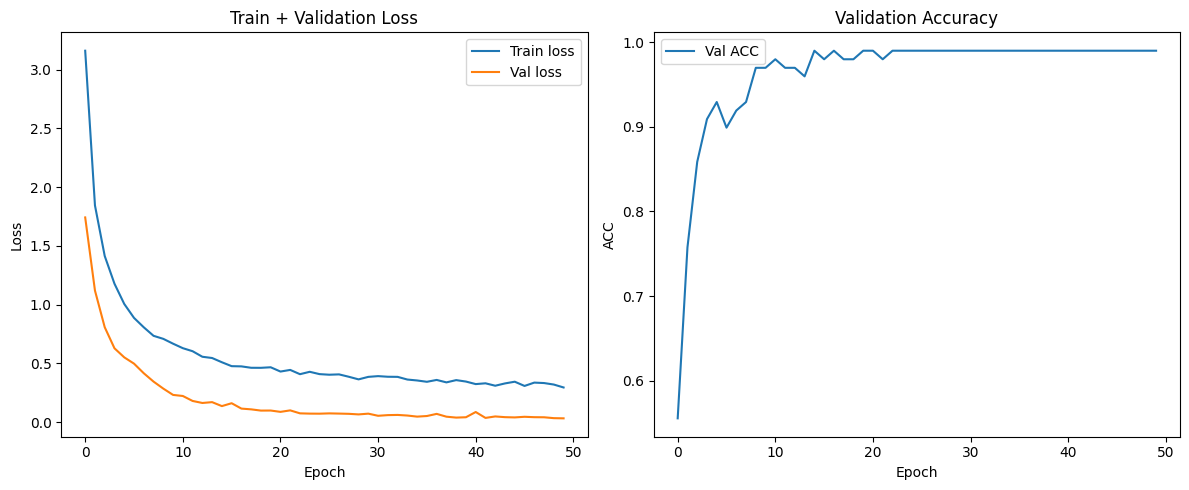

In [26]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

axes[0].plot(np.arange(EPOCHS), losses_train, label="Train loss")
cpu_losses_val = [tensor.cpu() for tensor in losses_val]
axes[0].plot(np.arange(EPOCHS), cpu_losses_val, label="Val loss")
axes[0].set_title("Train + Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(np.arange(EPOCHS), accs_val, label="Val ACC")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ACC")
axes[1].legend()

plt.tight_layout()
plt.show()

# Stopping point

# Save it

#### Save the weights

In [28]:
torch.save(base_model.state_dict(), getWeightsPath())

#### Save the model

In [28]:
torch.save(base_model, getModelPath())

In [29]:
def getModelScriptPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)

    if 'model_script' in dir_list:
        model_script_dir_path = os.path.join(path,'model_script')
    else:
        raise ValueError("Can't find 'model_script' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dirpath)
    timestr = time.strftime("%Y%m%d%H%M%S")
    model_file_name = os.path.join(model_script_dir_path,timestr) + ".pt"

    return model_file_name

In [30]:
torch_script_model = torch.jit.script(base_model)
torch.jit.save(torch_script_model,getModelScriptPath())